In [61]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal, List
import os
from langchain_openai import ChatOpenAI
# from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage
load_dotenv()

True

In [62]:
model = ChatGroq(model="llama-3.1-8b-instant", api_key=os.getenv("GROQ_API_KEY"), temperature=0.4,max_tokens=100)#type:ignore

In [63]:
class State(TypedDict):
    topic : str
    joke : str
    exp : str

In [64]:
def get_joke(state:State):
    prompt = f"Generate a joke on topic {state['topic']}"
    res = model.invoke(prompt).content
    return {'joke':res}

In [65]:
def get_explanation(state:State):
    prompt = f"Generate a explanation on the provided joke {state['joke']}"
    res = model.invoke(prompt).content
    return {'exp':res}

In [66]:
from langgraph.checkpoint.memory import InMemorySaver

In [67]:
checkpointer = InMemorySaver()
graph = StateGraph(State)

graph.add_node("get_joke",get_joke)
graph.add_node("get_explanation",get_explanation)

graph.add_edge(START,"get_joke")
graph.add_edge("get_joke","get_explanation")
graph.add_edge("get_explanation",END)

workflow = graph.compile(checkpointer=checkpointer)

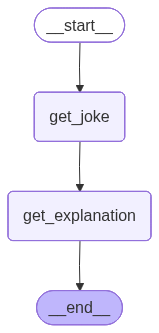

In [68]:
workflow

In [69]:
input_state = {'topic':'pizza'}
output_state = workflow.invoke(input_state,config={'configurable':{'thread_id':'1'}}) # type:ignore

In [70]:
output_state

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.',
 'exp': 'This joke is a play on words, which is a common technique used in puns. A pun is a form of wordplay that exploits multiple meanings of a word or phrase, often to create a humorous effect.\n\nIn this joke, the word "crusty" has a double meaning:\n\n1. A pizza crust is the outer layer of a pizza, which is typically made of bread or dough. So, in this context, "crusty" refers to the texture of the pizza crust.\n2'}

# Time Travel

In [71]:
list(workflow.get_state_history(config={'configurable':{'thread_id':'1'}}))#type:ignore

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'exp': 'This joke is a play on words, which is a common technique used in puns. A pun is a form of wordplay that exploits multiple meanings of a word or phrase, often to create a humorous effect.\n\nIn this joke, the word "crusty" has a double meaning:\n\n1. A pizza crust is the outer layer of a pizza, which is typically made of bread or dough. So, in this context, "crusty" refers to the texture of the pizza crust.\n2'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18206b-dfff-6984-8002-395715934c12'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-17T17:41:29.428006+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18206b-ddd0-6102-8001-a318924cfe71'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why wa

In [74]:
workflow.get_state(config={'configurable':{'thread_id':'1','checkpoint_id':'1f18206b-db45-67dc-8000-6c868dcdbe74'}})

StateSnapshot(values={'topic': 'pizza'}, next=('get_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f18206b-db45-67dc-8000-6c868dcdbe74'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-17T17:41:28.932348+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18206b-db43-60a4-bfff-1c46f1799499'}}, tasks=(PregelTask(id='b050118d-967f-cdc9-4306-50ee552b1f10', name='get_joke', path=('__pregel_pull', 'get_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.'}),), interrupts=())

In [75]:
workflow.invoke(None,config={'configurable':{'thread_id':'1','checkpoint_id':'1f18206b-db45-67dc-8000-6c868dcdbe74'}})

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.',
 'exp': 'This joke is a play on words, using a pun to create humor. The phrase "feeling a little crusty" has a double meaning here. \n\nIn everyday language, "feeling a little crusty" can refer to someone or something being in a bad mood, irritable, or grumpy. This is likely due to the idea that a crusty surface can be rough or unpleasant to interact with.\n\nHowever, in the context of a pizza, "crusty" has a different'}

In [76]:
list(workflow.get_state_history(config={'configurable':{'thread_id':'1'}}))#type:ignore

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'exp': 'This joke is a play on words, using a pun to create humor. The phrase "feeling a little crusty" has a double meaning here. \n\nIn everyday language, "feeling a little crusty" can refer to someone or something being in a bad mood, irritable, or grumpy. This is likely due to the idea that a crusty surface can be rough or unpleasant to interact with.\n\nHowever, in the context of a pizza, "crusty" has a different'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18206d-53c2-66ba-8002-38ca6368a146'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-17T17:42:08.409977+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18206d-5145-6b15-8001-fa766696b38b'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why wa

# Update State

In [78]:
workflow.update_state({'configurable':{'thread_id':'1','checkpoint_id':'1f18206b-db43-60a4-bfff-1c46f1799499','checkpoint_ns':''}},{'topic':'pasta'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18207b-44b6-6c2a-8000-b758e7576277'}}

In [79]:
list(workflow.get_state_history(config={'configurable':{'thread_id':'1'}}))#type:ignore

[StateSnapshot(values={'topic': 'pasta'}, next=('get_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18207b-44b6-6c2a-8000-b758e7576277'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-07-17T17:48:22.641975+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18206b-db43-60a4-bfff-1c46f1799499'}}, tasks=(PregelTask(id='8bb72d09-0856-29d3-fe8c-1588b4356c00', name='get_joke', path=('__pregel_pull', 'get_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'exp': 'This joke is a play on words, using a pun to create humor. The phrase "feeling a little crusty" has a double meaning here. \n\nIn everyday language, "feeling a little crusty" can refer to someone or something being in a bad mood, irritable, or grumpy. This is

In [80]:
workflow.invoke(None,config={'configurable':{'thread_id':'1','checkpoint_id':'1f18207b-44b6-6c2a-8000-b758e7576277'}})

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to therapy? \n\nBecause it was feeling a little "drained" and had a lot of "twisted" emotions.',
 'exp': 'This joke relies on wordplay to create a pun, which is a common technique used in humor. Here\'s a breakdown of the joke:\n\n1. **Setup**: The joke starts by asking a question, "Why did the spaghetti go to therapy?" This sets up the expectation that the answer will be a reason related to the spaghetti\'s emotional state or a situation it\'s in.\n\n2. **Punchline**: The answer "Because it was feeling a little \'drained\' and had a lot'}

In [81]:
list(workflow.get_state_history(config={'configurable':{'thread_id':'1'}}))#type:ignore

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy? \n\nBecause it was feeling a little "drained" and had a lot of "twisted" emotions.', 'exp': 'This joke relies on wordplay to create a pun, which is a common technique used in humor. Here\'s a breakdown of the joke:\n\n1. **Setup**: The joke starts by asking a question, "Why did the spaghetti go to therapy?" This sets up the expectation that the answer will be a reason related to the spaghetti\'s emotional state or a situation it\'s in.\n\n2. **Punchline**: The answer "Because it was feeling a little \'drained\' and had a lot'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f182080-22ca-6316-8002-9715bafe9c0c'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-17T17:50:33.302504+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f182080-2073-69eb-8001-bf12f984ef60'}}, tasks=(), inter